In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/creditcard.csv')

# Engineer Hour feature (we discovered this is useful!)
df['Hour'] = (df['Time'] / 3600) % 24

print("Data loaded successfully!")
print("Shape:", df.shape)

Data loaded successfully!
Shape: (284807, 32)


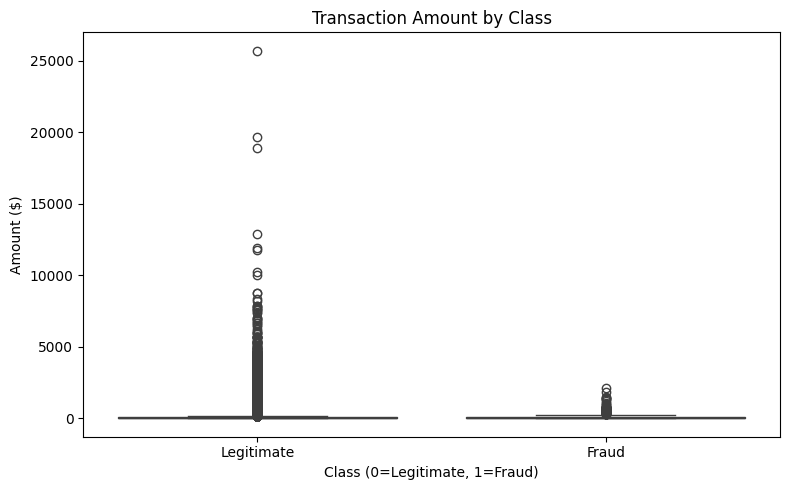

In [2]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.xlabel('Class (0=Legitimate, 1=Fraud)')
plt.ylabel('Amount ($)')
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.tight_layout()
plt.savefig('../visualizations/amount_boxplot.png')
plt.show()

MY UNDERSTANDING

LEGITIMATE:

Box is very flat at bottom  - most transactions under $500-$700

Lines going up              - some go up to $8,000

Circles above               - outliers up to $25,691 which are unusual large transactions


FRAUD:

Box is also flat at bottom  - most fraud under $500 - $700

Lines are shorter           - max around $2,125

Circles above               - a few larger fraud amounts

No very high outliers       - frauds dont make huge amount transactions


TOTAL:

Both boxes at bottom                - Most transactions are small

Legitimate has huge outliers        - Large purchases are legitimate

Fraud outliers max $2,125           - Frauds make small amount transaction

Both boxes similar size             - Amount alone can't separate fraud


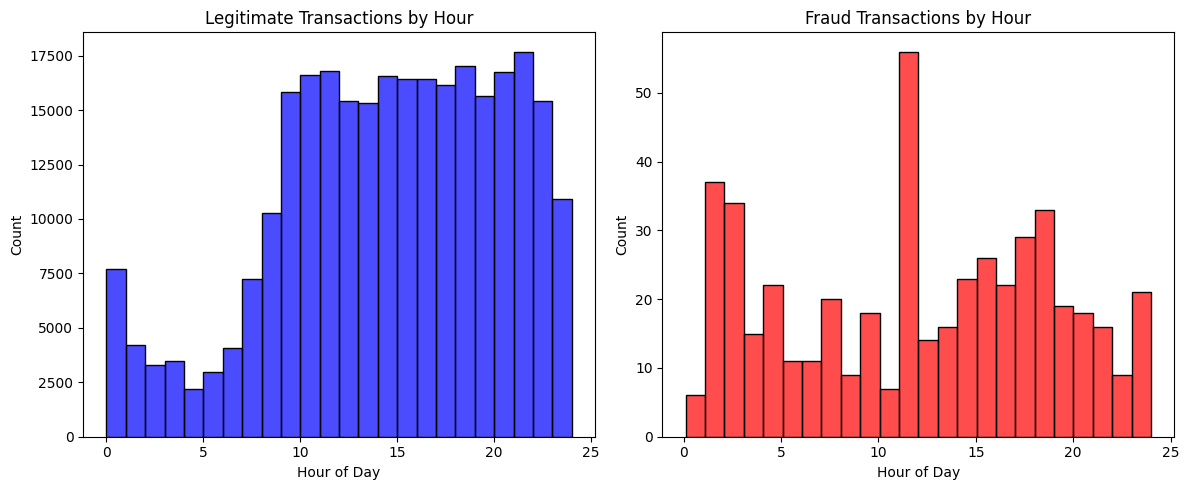

In [3]:
plt.figure(figsize=(12,5))

# Separate fraud and legitimate
fraud = df[df['Class']==1]
legit = df[df['Class']==0]

plt.subplot(1,2,1)
sns.histplot(legit['Hour'], bins=24, color='blue', alpha=0.7)
plt.title('Legitimate Transactions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')

plt.subplot(1,2,2)
sns.histplot(fraud['Hour'], bins=24, color='red', alpha=0.7)
plt.title('Fraud Transactions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('../visualizations/fraud_by_hour.png')
plt.show()

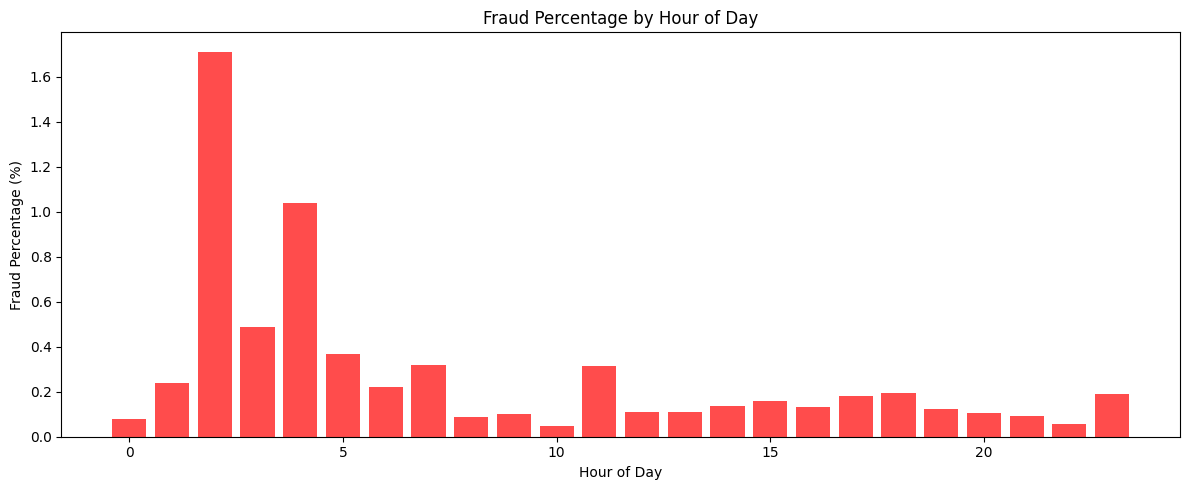


Hour with highest fraud percentage:
2 : 1.713 %


In [6]:
# Clean Hour column → whole numbers
# Group by hour → 24 buckets
# Count fraud and total per bucket
# Calculate fraud % per hour
# Draw bar chart
# Find most dangerous hour

# Round Hour to whole number
df['Hour'] = df['Hour'].astype(int)

# Now recalculate
hourly = df.groupby('Hour')['Class'].agg(['sum', 'count'])       #sort all transactions into 24 hour buckets,for each bucket calculate count and hour
hourly['fraud_pct'] = (hourly['sum'] / hourly['count']) * 100    #Creates new column fraud_pct

plt.figure(figsize=(12,5))
plt.bar(hourly.index, hourly['fraud_pct'], 
        color='red', alpha=0.7)
plt.title('Fraud Percentage by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Percentage (%)')
plt.tight_layout()
plt.savefig('../visualizations/fraud_percentage_by_hour.png')
plt.show()

print("\nHour with highest fraud percentage:")
print(hourly['fraud_pct'].idxmax(), 
      ":", hourly['fraud_pct'].max().round(3), "%")

#sum   = count fraud only
#count =all transcations

MY UNDERSTANDING:

2AM is most fraud transactions (1.713%) fraud rate

In [10]:
print("=" * 50)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 50)
print("""
1. AMOUNT (from boxplot):
   - Most transactions under $500
   - Legitimate has outliers up to $25,691
   - Fraud never exceeds $2,125
   - Fraudsters avoid large amounts

2. TIME (from hourly charts):
   - Legitimate follows business hours
   - Fraud happens at ALL hours
   - 2AM most dangerous = 1.713% fraud rate
  

3. CLASS IMBALANCE:
   - 99.83% legitimate
   - 0.17% fraud
   - Severe imbalance — need SMOTE
""")
print("=" * 50)

EDA SUMMARY — KEY FINDINGS

1. AMOUNT (from boxplot):
   - Most transactions under $500
   - Legitimate has outliers up to $25,691
   - Fraud never exceeds $2,125
   - Fraudsters avoid large amounts

2. TIME (from hourly charts):
   - Legitimate follows business hours
   - Fraud happens at ALL hours
   - 2AM most dangerous = 1.713% fraud rate


3. CLASS IMBALANCE:
   - 99.83% legitimate
   - 0.17% fraud
   - Severe imbalance — need SMOTE

